# 02 — Extracción inicial de pose

## Objetivo

Aplicar MediaPipe Pose sobre un video de referencia y comprobar que
los landmarks corporales pueden extraerse correctamente.

## Alcance de esta primera prueba

- Procesar un video.
- Leer sus frames.
- Detectar landmarks corporales.
- Registrar coordenadas, visibilidad y marcas de tiempo.
- Validar la detección antes de procesar los 10 videos.

## Limitaciones

Esta etapa todavía no compara movimientos ni calcula scores.

In [ ]:
from pathlib import Path
import csv
import cv2
import mediapipe as mp

PROJECT_ROOT = Path.cwd().parent
REFERENCE_DIR = PROJECT_ROOT / "data" / "raw" / "reference"
INVENTORY_PATH = PROJECT_ROOT / "data" / "metadata" / "reference_video_inventory.csv"

if not INVENTORY_PATH.exists():
    raise FileNotFoundError(f"No se encontró el inventario generado por el Notebook 01: {INVENTORY_PATH}")

with INVENTORY_PATH.open("r", newline="", encoding="utf-8") as file:
    inventory_rows = list(csv.DictReader(file))

if len(inventory_rows) != 10:
    raise ValueError("El inventario debe contener 10 videos de referencia")

video_path = REFERENCE_DIR / "gPO_sBM_c01_d10_mPO0_ch01.mp4"

if not video_path.exists():
    raise FileNotFoundError(f"No se encontró el video: {video_path}")

inventory_names = {row["file_name"] for row in inventory_rows}
inventory_paths = [REFERENCE_DIR / name for name in sorted(inventory_names)]
missing_inventory_files = [path for path in inventory_paths if not path.exists()]

if missing_inventory_files:
    raise FileNotFoundError(f"Faltan videos registrados en el inventario: {missing_inventory_files}")

print(f"Videos registrados en el inventario: {len(inventory_paths)}")
print(f"Video seleccionado para la prueba: {video_path.name}")

Videos registrados en el inventario: 10
Video seleccionado para la prueba: gPO_sBM_c01_d10_mPO0_ch01.mp4


In [2]:
mp_pose = mp.solutions.pose

pose_model = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)

print("Modelo MediaPipe Pose inicializado correctamente")

Modelo MediaPipe Pose inicializado correctamente


I0000 00:00:1785817112.117076       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2


## Prueba rápida del pipeline

Antes de procesar la secuencia completa, se revisan los primeros 30
frames del video de prueba. A 59.94 FPS representan aproximadamente
medio segundo. Esta prueba busca detectar errores de lectura del video,
conversión BGR/RGB y ejecución de MediaPipe; no constituye una evaluación
completa de la calidad de la pose ni del movimiento.

In [ ]:
capture = cv2.VideoCapture(str(video_path))

if not capture.isOpened():
    raise RuntimeError("No fue posible abrir el video")

fps = capture.get(cv2.CAP_PROP_FPS)
frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))

landmark_results = []
frame_index = 0

while frame_index < 30:
    success, frame = capture.read()

    if not success:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = pose_model.process(frame_rgb)

    landmarks = None

    if result.pose_landmarks:
        landmarks = [
            {
                "landmark_id": landmark_id,
                "x": landmark.x,
                "y": landmark.y,
                "z": landmark.z,
                "visibility": landmark.visibility
            }
            for landmark_id, landmark in enumerate(result.pose_landmarks.landmark)
        ]

    landmark_results.append({
        "frame_index": frame_index,
        "timestamp_sec": frame_index / fps,
        "detected": landmarks is not None,
        "landmarks": landmarks
    })

    frame_index += 1

capture.release()

detected_frames = sum(
    result["detected"]
    for result in landmark_results
)

print(f"Frames procesados: {len(landmark_results)}")
print(f"Frames con pose detectada: {detected_frames}")
print(f"FPS: {fps}")
print(f"Frames totales del video: {frame_count}")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Frames procesados: 30
Frames con pose detectada: 30
FPS: 59.94
Frames totales del video: 719


In [ ]:
from statistics import mean

detected_result = next(result for result in landmark_results if result["detected"])

landmarks = detected_result["landmarks"]

print(f"Landmarks detectados: {len(landmarks)}")
print("Primeros 3 landmarks:")

for landmark in landmarks[:3]:
    print(landmark)

visibility_values = [landmark["visibility"] for landmark in landmarks]

print(f"\nVisibilidad mínima: {min(visibility_values):.4f}")
print(f"Visibilidad promedio: {mean(visibility_values):.4f}")
print(f"Visibilidad máxima: {max(visibility_values):.4f}")

Landmarks detectados: 33
Primeros 3 landmarks:
{'landmark_id': 0, 'x': 0.49405232071876526, 'y': 0.43232887983322144, 'z': -0.13526064157485962, 'visibility': 0.9999501705169678}
{'landmark_id': 1, 'x': 0.4972866475582123, 'y': 0.42408397793769836, 'z': -0.12764054536819458, 'visibility': 0.9998351335525513}
{'landmark_id': 2, 'x': 0.4991500973701477, 'y': 0.4244210720062256, 'z': -0.12766313552856445, 'visibility': 0.9998204112052917}

Visibilidad mínima: 0.9066
Visibilidad promedio: 0.9796
Visibilidad máxima: 1.0000


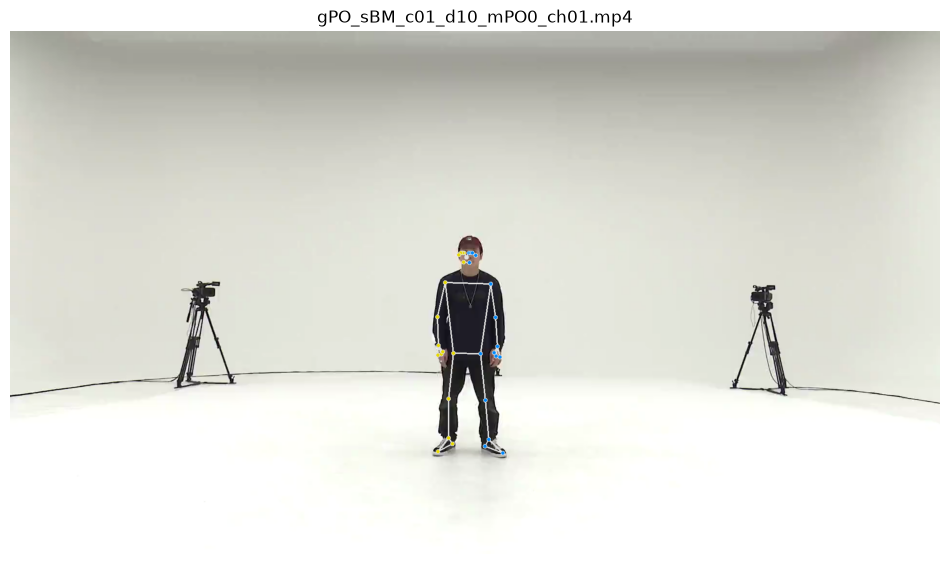

In [ ]:
import matplotlib.pyplot as plt

capture = cv2.VideoCapture(str(video_path))
success, frame = capture.read()
capture.release()

if not success:
    raise RuntimeError("No fue posible leer el primer frame")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
result = pose_model.process(frame_rgb)

if result.pose_landmarks is None:
    raise RuntimeError("No se detectó pose en el primer frame")

annotated_frame = frame_rgb.copy()

mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_drawing.draw_landmarks(annotated_frame, result.pose_landmarks, mp_pose.POSE_CONNECTIONS, landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style())
plt.figure(figsize=(12, 7))
plt.imshow(annotated_frame)
plt.axis("off")
plt.title(video_path.name)
plt.show()

## Validación visual inicial

La detección de MediaPipe sobre el video seleccionado es adecuada.
Se identifica una sola persona con el cuerpo completo visible y los
landmarks se distribuyen correctamente sobre cabeza, torso, brazos y
piernas.

La persona ocupa una región central relativamente pequeña del cuadro,
pero no se observan pérdidas evidentes de landmarks ni confusión con
las cámaras visibles en el fondo.

## Extensión de la prueba rápida al conjunto de referencia

Una vez comprobado el video de prueba, se repite la misma revisión de
30 frames en los diez videos registrados por el Notebook 01. Esta etapa
sirve como control preliminar de compatibilidad del conjunto completo;
la decisión de calidad se tomará después del procesamiento de todos los
frames.

In [ ]:
PROJECT_ROOT = Path.cwd().parent
REFERENCE_DIR = PROJECT_ROOT / "data" / "raw" / "reference"

downloaded_files = [REFERENCE_DIR / row["file_name"] for row in inventory_rows]

if len(downloaded_files) != len(inventory_rows):
    raise ValueError("El inventario y la lista de videos no coinciden")

print(f"Videos encontrados: {len(downloaded_files)}")

for video_path in downloaded_files:
    print(video_path.name)

Videos encontrados: 10
gBR_sBM_c01_d04_mBR0_ch01.mp4
gHO_sBM_c01_d19_mHO0_ch01.mp4
gJB_sBM_c01_d07_mJB0_ch01.mp4
gJS_sBM_c01_d01_mJS0_ch01.mp4
gKR_sBM_c01_d28_mKR0_ch01.mp4
gLH_sBM_c01_d16_mLH0_ch01.mp4
gLO_sBM_c01_d13_mLO0_ch01.mp4
gMH_sBM_c01_d22_mMH0_ch01.mp4
gPO_sBM_c01_d10_mPO0_ch01.mp4
gWA_sBM_c01_d25_mWA0_ch01.mp4


In [ ]:
pose_quality_summary = []

for current_video_path in downloaded_files:
    capture = cv2.VideoCapture(str(current_video_path))

    if not capture.isOpened():
        pose_quality_summary.append({
            "file_name": current_video_path.name,
            "frames_processed": 0,
            "detected_frames": 0,
            "detection_rate": 0,
            "avg_visibility": None,
            "min_visibility": None
        })
        continue

    current_fps = capture.get(cv2.CAP_PROP_FPS)
    frames_processed = 0
    detected_frames = 0
    visibility_values = []

    with mp_pose.Pose(
        static_image_mode=False,
        model_complexity=1,
        enable_segmentation=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as current_pose_model:

        while frames_processed < 30:
            success, frame = capture.read()

            if not success:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = current_pose_model.process(frame_rgb)

            if result.pose_landmarks:
                detected_frames += 1
                visibility_values.extend(landmark.visibility for landmark in result.pose_landmarks.landmark)

            frames_processed += 1

    capture.release()

    pose_quality_summary.append({
        "file_name": current_video_path.name,
        "frames_processed": frames_processed,
        "detected_frames": detected_frames,
        "detection_rate": round(detected_frames / frames_processed, 3) if frames_processed else 0,
        "avg_visibility": round(sum(visibility_values) / len(visibility_values), 4) if visibility_values else None,
        "min_visibility": round(min(visibility_values), 4) if visibility_values else None,
        "fps": round(current_fps, 3)
    })

for summary in pose_quality_summary:
    print(summary)

I0000 00:00:1785817113.152892       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817113.779744       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817114.422754       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817115.170119       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817115.843093       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817116.468755       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817117.103357       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817117.718010       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817118.327280       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: A

{'file_name': 'gBR_sBM_c01_d04_mBR0_ch01.mp4', 'frames_processed': 30, 'detected_frames': 30, 'detection_rate': 1.0, 'avg_visibility': 0.9733, 'min_visibility': 0.6213, 'fps': 59.94}
{'file_name': 'gHO_sBM_c01_d19_mHO0_ch01.mp4', 'frames_processed': 30, 'detected_frames': 30, 'detection_rate': 1.0, 'avg_visibility': 0.9586, 'min_visibility': 0.7203, 'fps': 59.94}
{'file_name': 'gJB_sBM_c01_d07_mJB0_ch01.mp4', 'frames_processed': 30, 'detected_frames': 29, 'detection_rate': 0.967, 'avg_visibility': 0.9327, 'min_visibility': 0.5012, 'fps': 59.94}
{'file_name': 'gJS_sBM_c01_d01_mJS0_ch01.mp4', 'frames_processed': 30, 'detected_frames': 30, 'detection_rate': 1.0, 'avg_visibility': 0.98, 'min_visibility': 0.8995, 'fps': 59.94}
{'file_name': 'gKR_sBM_c01_d28_mKR0_ch01.mp4', 'frames_processed': 30, 'detected_frames': 30, 'detection_rate': 1.0, 'avg_visibility': 0.9421, 'min_visibility': 0.3859, 'fps': 59.94}
{'file_name': 'gLH_sBM_c01_d16_mLH0_ch01.mp4', 'frames_processed': 30, 'detected_fram

In [ ]:
from statistics import mean

full_pose_quality_summary = []

for current_video_path in downloaded_files:
    capture = cv2.VideoCapture(str(current_video_path))

    if not capture.isOpened():
        full_pose_quality_summary.append({
            "file_name": current_video_path.name,
            "frames_processed": 0,
            "detected_frames": 0,
            "detection_rate": 0,
            "avg_visibility": None,
            "min_visibility": None,
            "low_quality_frame_rate": None
        })
        continue

    current_fps = capture.get(cv2.CAP_PROP_FPS)
    frames_processed = 0
    detected_frames = 0
    all_visibility_values = []
    frame_average_visibility = []

    with mp_pose.Pose(
        static_image_mode=False,
        model_complexity=1,
        enable_segmentation=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as current_pose_model:

        while True:
            success, frame = capture.read()

            if not success:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = current_pose_model.process(frame_rgb)

            if result.pose_landmarks:
                detected_frames += 1
                current_visibility = [landmark.visibility for landmark in result.pose_landmarks.landmark]
                all_visibility_values.extend(current_visibility) 
                frame_average_visibility.append(mean(current_visibility))

            frames_processed += 1

    capture.release()

    low_quality_frames = [visibility for visibility in frame_average_visibility if visibility < 0.5]

    full_pose_quality_summary.append({
        "file_name": current_video_path.name,
        "frames_processed": frames_processed,
        "detected_frames": detected_frames,
        "detection_rate": round(detected_frames / frames_processed, 3) if frames_processed else 0,
        "avg_visibility": round(mean(all_visibility_values), 4) if all_visibility_values else None,
        "min_visibility": round(min(all_visibility_values), 4) if all_visibility_values else None,
        "low_quality_frame_rate": round(len(low_quality_frames) / len(frame_average_visibility), 3) if frame_average_visibility else None,
        "fps": round(current_fps, 3)
    })

for summary in full_pose_quality_summary:
    print(summary)

I0000 00:00:1785817119.560832       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817132.798112       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817142.426692       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817155.997598       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817169.390975       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817183.260611       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817196.771472       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817210.139211       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
I0000 00:00:1785817223.088798       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: A

{'file_name': 'gBR_sBM_c01_d04_mBR0_ch01.mp4', 'frames_processed': 719, 'detected_frames': 719, 'detection_rate': 1.0, 'avg_visibility': 0.9566, 'min_visibility': 0.4221, 'low_quality_frame_rate': 0.0, 'fps': 59.94}
{'file_name': 'gHO_sBM_c01_d19_mHO0_ch01.mp4', 'frames_processed': 523, 'detected_frames': 523, 'detection_rate': 1.0, 'avg_visibility': 0.9391, 'min_visibility': 0.2627, 'low_quality_frame_rate': 0.0, 'fps': 59.94}
{'file_name': 'gJB_sBM_c01_d07_mJB0_ch01.mp4', 'frames_processed': 719, 'detected_frames': 718, 'detection_rate': 0.999, 'avg_visibility': 0.8389, 'min_visibility': 0.1815, 'low_quality_frame_rate': 0.0, 'fps': 59.94}
{'file_name': 'gJS_sBM_c01_d01_mJS0_ch01.mp4', 'frames_processed': 719, 'detected_frames': 719, 'detection_rate': 1.0, 'avg_visibility': 0.9827, 'min_visibility': 0.8309, 'low_quality_frame_rate': 0.0, 'fps': 59.94}
{'file_name': 'gKR_sBM_c01_d28_mKR0_ch01.mp4', 'frames_processed': 719, 'detected_frames': 719, 'detection_rate': 1.0, 'avg_visibility

## Resultado de la validación completa

MediaPipe Pose detectó correctamente la pose en los 10 videos de
referencia.

Nueve videos tuvieron detección en el 100% de sus frames y uno alcanzó
99.9%. La visibilidad promedio fue adecuada en todos los casos y no se
identificaron frames cuya visibilidad corporal promedio fuera inferior
al umbral establecido.

Algunos videos presentan landmarks individuales con visibilidad baja en
momentos puntuales. Esto no invalida el video completo, pero deberá
considerarse durante la ingeniería de variables y el cálculo de
similitud.

In [ ]:
import csv

pose_quality_file = (PROJECT_ROOT / "data" / "metadata" / "pose_quality_summary.csv")

fieldnames = list(full_pose_quality_summary[0].keys())

with pose_quality_file.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(full_pose_quality_summary)

print(f"Resumen guardado en: {pose_quality_file}")

Resumen guardado en: /Users/igayvid/Library/Mobile Documents/com~apple~CloudDocs/Documents/05-aprendizaje/diplomado-ciencia-datos/05-modulo-integrador/mitotl-ia/data/metadata/pose_quality_summary.csv


I0000 00:00:1785817249.738023       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2


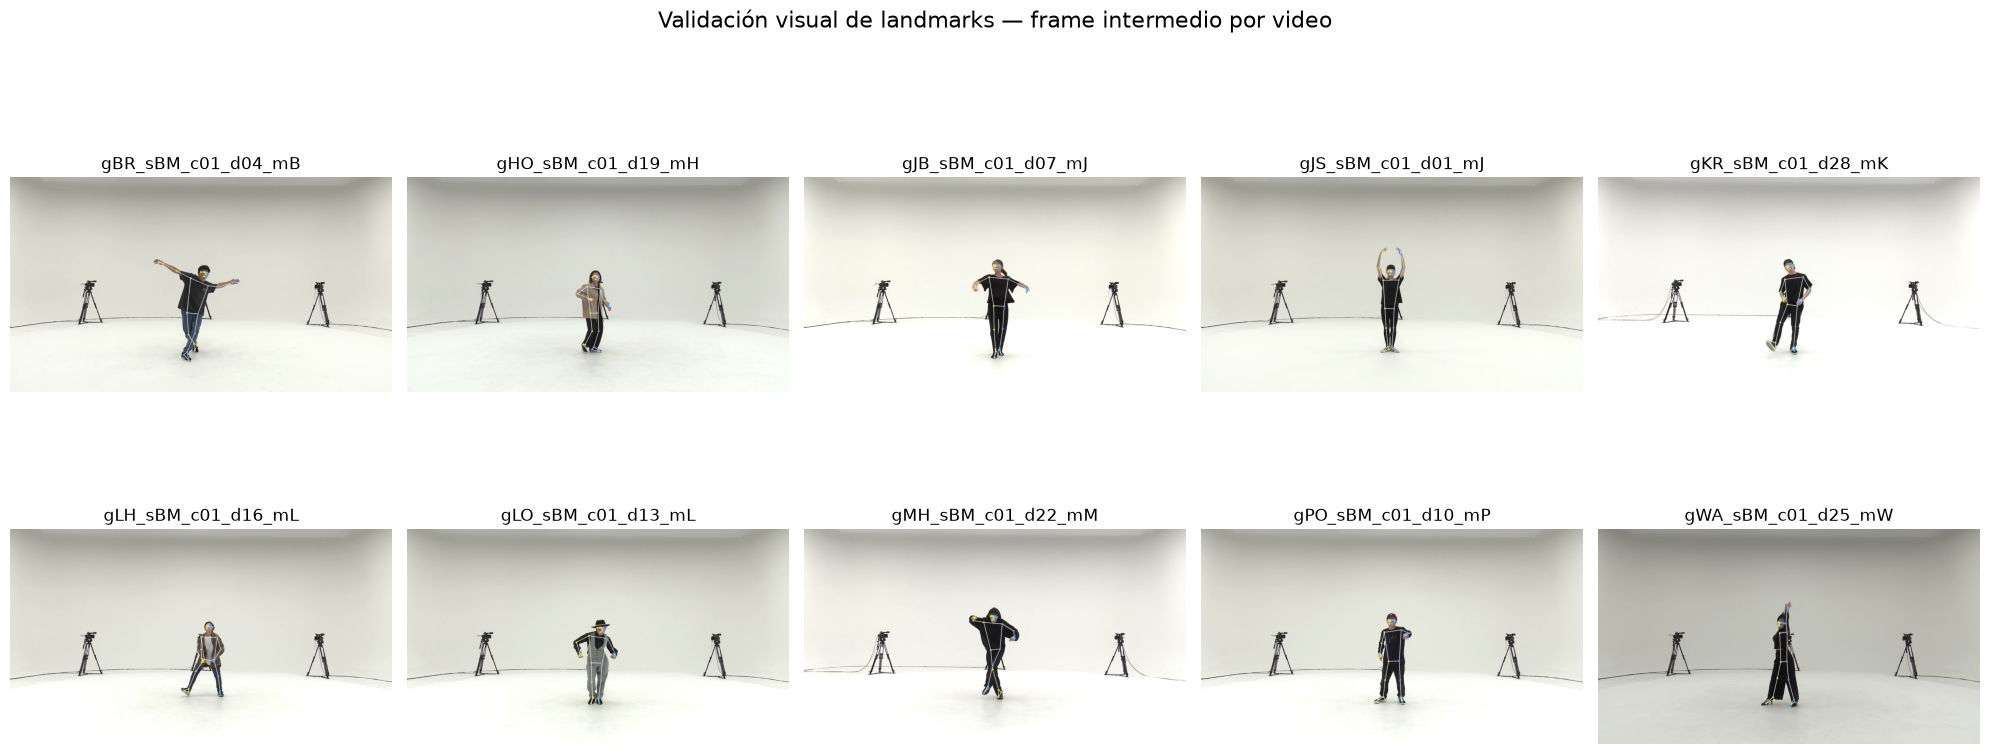

In [10]:
import matplotlib.pyplot as plt

mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

with mp_pose.Pose(
    static_image_mode=True,
    model_complexity=1,
    enable_segmentation=False,
    min_detection_confidence=0.5,
) as visualization_pose_model:

    for axis, current_video_path in zip(axes, downloaded_files):
        capture = cv2.VideoCapture(str(current_video_path))

        frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
        middle_frame_index = frame_count // 2

        capture.set(cv2.CAP_PROP_POS_FRAMES, middle_frame_index)
        success, frame = capture.read()
        capture.release()

        if not success:
            axis.set_title(f"{current_video_path.name}\nError")
            axis.axis("off")
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = visualization_pose_model.process(frame_rgb)

        if result.pose_landmarks:
            annotated_frame = frame_rgb.copy()

            mp_drawing.draw_landmarks(
                annotated_frame,
                result.pose_landmarks,
                mp_pose.POSE_CONNECTIONS,
                landmark_drawing_spec=(
                    mp_drawing_styles
                    .get_default_pose_landmarks_style()
                ),
            )

            axis.imshow(annotated_frame)
            axis.set_title(current_video_path.stem[:18])
        else:
            axis.imshow(frame_rgb)
            axis.set_title(f"{current_video_path.stem[:18]}\nSin pose")

        axis.axis("off")

plt.suptitle(
    "Validación visual de landmarks — frame intermedio por video",
    fontsize=16,
)
plt.tight_layout()
plt.show()

## Resultado de la validación visual

La detección visual de landmarks es adecuada en los 10 videos. Todos
muestran una sola persona con el cuerpo completo visible y una correcta
ubicación general de los puntos corporales.

Algunas ejecuciones incluyen posturas laterales, brazos cruzados,
extremidades parcialmente ocultas o movimientos que reducen la
visibilidad de landmarks específicos. Estas situaciones no invalidan
los videos, pero deberán manejarse mediante las variables de visibilidad
durante la comparación de movimientos.

In [ ]:
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

landmarks_figure_path = (ARTIFACTS_DIR / "landmarks_validation_all_videos.png")

fig.savefig(landmarks_figure_path, dpi=150, bbox_inches="tight")

print(f"Figura guardada en: {landmarks_figure_path}")

Figura guardada en: /Users/igayvid/Library/Mobile Documents/com~apple~CloudDocs/Documents/05-aprendizaje/diplomado-ciencia-datos/05-modulo-integrador/mitotl-ia/artifacts/landmarks_validation_all_videos.png


## Contrato de salida de la extracción

La extracción completa generará un JSON por cada video. Cada archivo
conservará la secuencia temporal completa e incluirá `frame_index`,
`timestamp_sec`, `detected` y, cuando exista detección, 33 landmarks con
coordenadas `x`, `y`, `z` y `visibility`. Los frames sin detección se
mantendrán con `landmarks=None` para no romper la alineación temporal.

In [ ]:
import json

POSE_DATA_DIR = (PROJECT_ROOT / "data" / "derived" / "pose")
POSE_DATA_DIR.mkdir(parents=True, exist_ok=True)

pose_files = []

for current_video_path in downloaded_files:
    print(f"Procesando: {current_video_path.name}")

    capture = cv2.VideoCapture(str(current_video_path))

    if not capture.isOpened():
        print("  No se pudo abrir")
        continue

    current_fps = capture.get(cv2.CAP_PROP_FPS)
    current_frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))

    frames = []
    frame_index = 0

    with mp_pose.Pose(
        static_image_mode=False,
        model_complexity=1,
        enable_segmentation=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as current_pose_model:

        while True:
            success, frame = capture.read()

            if not success:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = current_pose_model.process(frame_rgb)

            frame_data = {
                "frame_index": frame_index,
                "timestamp_sec": round(frame_index / current_fps, 6),
                "detected": False,
                "landmarks": None
            }

            if result.pose_landmarks:
                frame_data["detected"] = True
                frame_data["landmarks"] = [
                    {
                        "landmark_id": landmark_id,
                        "x": landmark.x,
                        "y": landmark.y,
                        "z": landmark.z,
                        "visibility": landmark.visibility,
                    }
                    for landmark_id, landmark
                    in enumerate(result.pose_landmarks.landmark)
                ]

            frames.append(frame_data)
            frame_index += 1

    capture.release()

    pose_data = {
        "source_video": current_video_path.name,
        "model": "MediaPipe Pose",
        "model_complexity": 1,
        "landmark_count": 33,
        "fps": current_fps,
        "frame_count": current_frame_count,
        "frames": frames
    }

    output_path = POSE_DATA_DIR / (f"{current_video_path.stem}_pose.json")

    with output_path.open("w", encoding="utf-8") as file:
        json.dump(pose_data, file, ensure_ascii=False)

    pose_files.append(output_path)
    print(f"  Guardado: {output_path.name}")

print(f"\nArchivos generados: {len(pose_files)}")

Procesando: gBR_sBM_c01_d04_mBR0_ch01.mp4


I0000 00:00:1785817254.805256       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2


  Guardado: gBR_sBM_c01_d04_mBR0_ch01_pose.json
Procesando: gHO_sBM_c01_d19_mHO0_ch01.mp4


I0000 00:00:1785817268.311090       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2


  Guardado: gHO_sBM_c01_d19_mHO0_ch01_pose.json
Procesando: gJB_sBM_c01_d07_mJB0_ch01.mp4


...

  Guardado: gMH_sBM_c01_d22_mMH0_ch01_pose.json
Procesando: gPO_sBM_c01_d10_mPO0_ch01.mp4


I0000 00:00:1785817363.624571       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2


  Guardado: gPO_sBM_c01_d10_mPO0_ch01_pose.json
Procesando: gWA_sBM_c01_d25_mWA0_ch01.mp4


I0000 00:00:1785817377.793709       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2


  Guardado: gWA_sBM_c01_d25_mWA0_ch01_pose.json

Archivos generados: 10


In [13]:
for path in pose_files:
    print(
        path.name,
        f"{path.stat().st_size / (1024 ** 2):.2f} MB"
    )

gBR_sBM_c01_d04_mBR0_ch01_pose.json 3.03 MB
gHO_sBM_c01_d19_mHO0_ch01_pose.json 2.21 MB
gJB_sBM_c01_d07_mJB0_ch01_pose.json 3.03 MB
gJS_sBM_c01_d01_mJS0_ch01_pose.json 3.04 MB
gKR_sBM_c01_d28_mKR0_ch01_pose.json 3.04 MB
gLH_sBM_c01_d16_mLH0_ch01_pose.json 3.03 MB
gLO_sBM_c01_d13_mLO0_ch01_pose.json 3.03 MB
gMH_sBM_c01_d22_mMH0_ch01_pose.json 3.04 MB
gPO_sBM_c01_d10_mPO0_ch01_pose.json 3.04 MB
gWA_sBM_c01_d25_mWA0_ch01_pose.json 3.04 MB


In [14]:
import json

pose_validation = []

for pose_path in pose_files:
    with pose_path.open("r", encoding="utf-8") as file:
        pose_data = json.load(file)

    detected_frames = 0
    invalid_landmark_frames = 0
    invalid_missing_frame_records = 0
    frame_indices = [frame["frame_index"] for frame in pose_data["frames"]]
    timestamps = [frame["timestamp_sec"] for frame in pose_data["frames"]]

    for frame in pose_data["frames"]:
        if frame["detected"]:
            detected_frames += 1

            if (
                frame["landmarks"] is None
                or len(frame["landmarks"]) != 33
            ):
                invalid_landmark_frames += 1
        elif frame["landmarks"] is not None:
            invalid_missing_frame_records += 1

    pose_validation.append({
        "file_name": pose_path.name,
        "frames": len(pose_data["frames"]),
        "expected_frames": pose_data["frame_count"],
        "landmark_count": pose_data["landmark_count"],
        "detected_frames": detected_frames,
        "invalid_landmark_frames": invalid_landmark_frames,
        "invalid_missing_frame_records": invalid_missing_frame_records,
        "indices_ordered": frame_indices == list(range(len(frame_indices))),
        "timestamps_ordered": timestamps == sorted(timestamps),
        "valid": (
            len(pose_data["frames"]) == pose_data["frame_count"]
            and pose_data["landmark_count"] == 33
            and pose_data["fps"] > 0
            and invalid_landmark_frames == 0
            and invalid_missing_frame_records == 0
            and frame_indices == list(range(len(frame_indices)))
            and timestamps == sorted(timestamps)
        ),
    })

for result in pose_validation:
    print(result)

{'file_name': 'gBR_sBM_c01_d04_mBR0_ch01_pose.json', 'frames': 719, 'expected_frames': 719, 'landmark_count': 33, 'detected_frames': 719, 'invalid_landmark_frames': 0, 'invalid_missing_frame_records': 0, 'indices_ordered': True, 'timestamps_ordered': True, 'valid': True}
{'file_name': 'gHO_sBM_c01_d19_mHO0_ch01_pose.json', 'frames': 523, 'expected_frames': 523, 'landmark_count': 33, 'detected_frames': 523, 'invalid_landmark_frames': 0, 'invalid_missing_frame_records': 0, 'indices_ordered': True, 'timestamps_ordered': True, 'valid': True}
{'file_name': 'gJB_sBM_c01_d07_mJB0_ch01_pose.json', 'frames': 719, 'expected_frames': 719, 'landmark_count': 33, 'detected_frames': 718, 'invalid_landmark_frames': 0, 'invalid_missing_frame_records': 0, 'indices_ordered': True, 'timestamps_ordered': True, 'valid': True}
{'file_name': 'gJS_sBM_c01_d01_mJS0_ch01_pose.json', 'frames': 719, 'expected_frames': 719, 'landmark_count': 33, 'detected_frames': 719, 'invalid_landmark_frames': 0, 'invalid_missing

## Resultado final del Notebook 02

La extracción completa de pose se realizó correctamente sobre los 10
videos de referencia.

Cada archivo contiene el número esperado de frames, timestamps ordenados
y 33 landmarks por frame detectado. Los índices de frame son consecutivos
y no se encontraron estructuras corruptas.

Un video presenta un frame sin detección (`gJB`, 718 de 719 frames),
por lo que las siguientes etapas deberán contemplar el manejo de frames
faltantes. Esta situación no invalida el conjunto exploratorio.

La visibilidad se conserva como indicador técnico de confianza del
landmark; todavía no representa una etiqueta de calidad de danza. Estos
JSON serán la entrada del Notebook 03 para normalización, agrupación por
parte corporal, ángulos, velocidades y demás variables derivadas.